# **Project Name** - DeepCSAT – Ecommerce Customer Satisfaction Score Prediction




##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

`This project focuses on building a machine learning solution to analyze customer feedback and predict customer satisfaction levels. Understanding customer sentiment and satisfaction is extremely important for businesses because it helps them identify areas of improvement, enhance service quality, and make data-driven decisions. The objective of this project was to develop a predictive model capable of analyzing various features, including customer remarks, and accurately classifying satisfaction levels.`

`The first stage of the project involved data preprocessing and exploratory analysis. The dataset was examined to understand the structure, feature types, and potential issues such as missing values or inconsistent data. During this stage, necessary cleaning operations were performed to ensure the dataset was suitable for machine learning. Text data present in the customer remarks column was processed using standard natural language processing techniques such as removing stopwords, tokenization, and basic text normalization. This helped convert raw textual feedback into a structured form that could be used by machine learning algorithms.`

`After preprocessing the text data, feature engineering and transformation techniques were applied. Categorical variables were encoded into numerical representations so that machine learning models could process them effectively. Numerical features were scaled to maintain uniformity across features and prevent models from being biased toward variables with larger magnitudes. Dimensionality reduction techniques were also considered to reduce unnecessary complexity in the dataset and improve computational efficiency.`

`The dataset was then divided into training and testing sets to evaluate the performance of the models on unseen data. A train-test split ratio of 80:20 was used, which is a commonly adopted practice in machine learning. This approach ensures that the model has sufficient data for training while still retaining a portion of the data for unbiased performance evaluation.`

`During the analysis, it was observed that the dataset exhibited class imbalance, meaning some satisfaction levels appeared more frequently than others. To address this issue, the SMOTE (Synthetic Minority Oversampling Technique) method was applied. SMOTE generates synthetic samples for minority classes, helping the model learn balanced patterns and improving its ability to generalize across all categories.`

`Three different machine learning models were implemented and evaluated in this project: Random Forest, Artificial Neural Network (ANN), and XGBoost. These models were selected because they represent different machine learning paradigms and are widely used for classification tasks. Random Forest is an ensemble learning method based on decision trees, ANN is a deep learning approach capable of learning complex patterns, and XGBoost is a highly efficient gradient boosting algorithm known for its strong predictive performance.`

`To improve the performance of these models, cross-validation and hyperparameter tuning were applied. RandomizedSearchCV was used for hyperparameter optimization because it efficiently explores different parameter combinations without evaluating every possible configuration. This approach significantly reduces training time while still identifying good model configurations.`

`After training and evaluating the models, their performance was compared using accuracy as the primary evaluation metric. Among the three models, XGBoost achieved the highest accuracy, making it the most suitable model for predicting customer satisfaction in this dataset.`

`To further enhance model transparency, model explainability techniques were applied using SHAP (SHapley Additive exPlanations). SHAP analysis helped identify the most influential features contributing to the model's predictions. This is particularly valuable for businesses because it highlights the key factors affecting customer satisfaction, enabling organizations to focus on areas that directly impact customer experience.`

`Finally, the trained models were saved using the Joblib library, allowing them to be reused for future predictions without retraining. The models were then reloaded and tested on unseen data to ensure successful serialization and correct functionality.`

`Overall, this project demonstrates how machine learning techniques can be applied to analyze customer feedback and predict satisfaction levels. The developed solution can assist businesses in gaining actionable insights from customer data and making informed decisions to improve service quality and customer experience.`

# **GitHub Link -**

https://github.com/Rupeshyadv/Deep_CSAT

# **Problem Statement**


`The objective of this project is to build a predictive model using an Artificial Neural Network (ANN) to classify customer satisfaction levels based on various input features such as customer interaction details and remarks. ANN is chosen because it is capable of learning complex patterns and relationships in data, making it suitable for solving classification problems involving multiple features.`

`The developed model will help businesses quickly identify satisfaction trends and take appropriate actions to improve customer experience and service quality.`

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv("./data/raw_data/eCommerce_Customer_support_data.csv")

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape  # 85907 rows & 20 cols

(85907, 20)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent
})

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

print(missing_df)

                         Missing Count  Missing Percentage (%)
Customer Remarks                 57165               66.542889
Order_id                         18232               21.222950
order_date_time                  68693               79.962052
Customer_City                    68828               80.119199
Product_category                 68711               79.983005
Item_price                       68701               79.971364
connected_handling_time          85665               99.718300


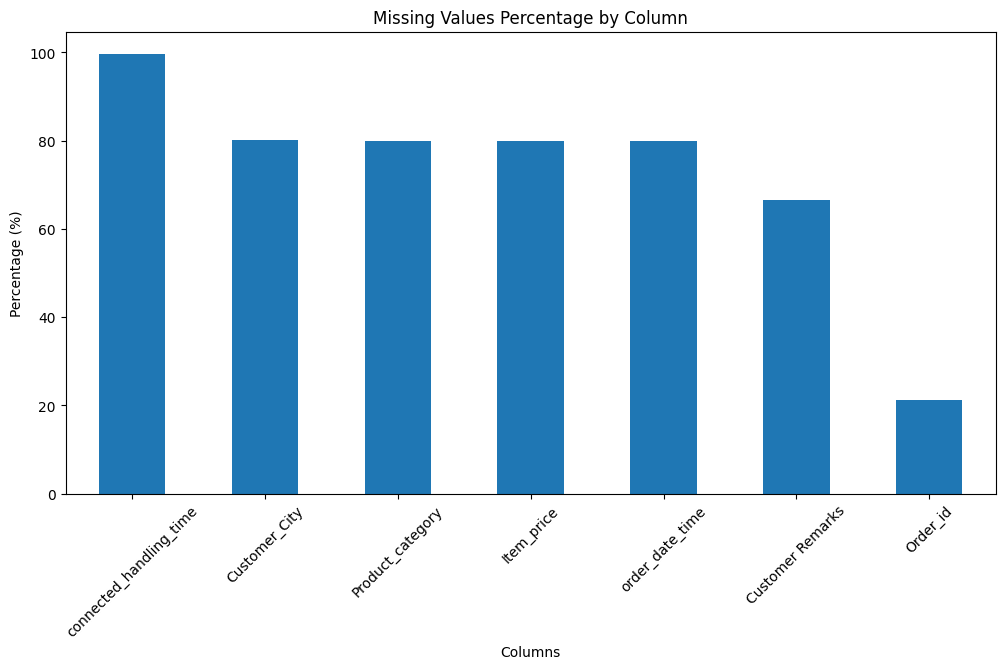

In [8]:
# Visualizing the missing values
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing_percent.plot(kind='bar')
plt.title("Missing Values Percentage by Column")
plt.ylabel("Percentage (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.show()

### What did you know about your dataset?

## 📊 Dataset Overview & Initial Observations

The dataset contains **85,907 rows and 20 columns**, indicating a moderately large dataset suitable for machine learning modeling. No duplicate records were found, ensuring data consistency and uniqueness.

### 🔍 Missing Values Analysis

A detailed missing value analysis revealed the following key observations:

- **Customer Remarks** has approximately **66.5% missing values**, which may limit the effectiveness of text-based sentiment analysis unless handled carefully.

- The following columns have around **80% missing values**:
  - `order_date_time`
  - `Customer_City`
  - `Product_category`
  - `Item_price`

  These columns will require careful consideration for imputation or potential removal depending on their importance in predicting CSAT.

- **connected_handling_time** has approximately **99.7% missing values**, making it nearly unusable in its current state. This column may need to be dropped from the analysis.

### 🧠 Key Insights

- The dataset is clean in terms of duplicate entries.
- However, several important operational features have a high proportion of missing values.
- Proper feature selection and preprocessing will be critical before model development.
- The missingness may indicate data collection inconsistencies or system-level recording issues.

These observations will guide the data preprocessing and feature engineering steps in subsequent stages of the project.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print("Total Columns:", len(df.columns))
print("\nColumn Names:")
for col in df.columns:
    print("-", col)

Total Columns: 20

Column Names:
- Unique id
- channel_name
- category
- Sub-category
- Customer Remarks
- Order_id
- order_date_time
- Issue_reported at
- issue_responded
- Survey_response_Date
- Customer_City
- Product_category
- Item_price
- connected_handling_time
- Agent_name
- Supervisor
- Manager
- Tenure Bucket
- Agent Shift
- CSAT Score


In [10]:
# Dataset Describe
df.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


### Variables Description

## Variables Description

| Variable Name              | Description                                                         | Data Type        |
|----------------------------|---------------------------------------------------------------------|------------------|
| Unique id                  | Unique identifier for each record                                   | Integer          |
| Channel name               | Name of the customer service channel                                | Object/String    |
| Category                   | Category of the interaction                                         | Object/String    |
| Sub-category               | Sub-category of the interaction                                     | Object/String    |
| Customer Remarks           | Feedback provided by the customer                                   | Object/String    |
| Order_id                   | Identifier for the order associated with the interaction            | Integer          |
| Order date time            | Date and time of the order                                          | Datetime         |
| Issue reported at          | Timestamp when the issue was reported                               | Datetime         |
| Issue responded            | Timestamp when the issue was responded to                           | Datetime         |
| Survey response date       | Date of the customer survey response                                | Datetime         |
| Customer city              | City of the customer                                                | Object/String    |
| Product category           | Category of the product                                             | Object/String    |
| Item price                 | Price of the item                                                   | Float            |
| Connected handling time    | Time taken to handle the interaction                                | Float            |
| Agent_name                 | Name of the customer service agent                                  | Object/String    |
| Supervisor                 | Name of the supervisor                                              | Object/String    |
| Manager                    | Name of the manager                                                 | Object/String    |
| Tenure Bucket              | Bucket categorizing agent tenure                                    | Object/String    |
| Agent Shift                | Shift timing of the agent                                           | Object/String    |
| CSAT Score                 | Customer Satisfaction Score                                         | Integer          |

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
unique_counts = df.nunique().reset_index()
unique_counts.columns = ['Column', 'Unique Values']
unique_counts.sort_values(by='Unique Values', ascending=False)

,Column,Unique Values
0,Unique id,85907
5,Order_id,67675
7,Issue_reported at,30923
8,issue_responded,30262
4,Customer Remarks,18231
6,order_date_time,13766
12,Item_price,2789
10,Customer_City,1782
14,Agent_name,1371
13,connected_handling_time,211


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Make a copy of original dataset
df_clean = df.copy()

# 1. Drop columns with >70% missing values
missing_percentage = df_clean.isnull().mean()

cols_to_drop = missing_percentage[missing_percentage > 0.7].index
df_clean.drop(columns=cols_to_drop, inplace=True)

print("Dropped Columns ( >70% missing ):")
print(cols_to_drop)

# 2. Convert date columns to datetime (if present)
date_cols = [
    'order_date_time',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'
]

for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# 3. Drop irrelevant ID columns
irrelevant_cols = ['Unique id', 'Order_id', 'Agent_name', 'Supervisor', 'Manager']

for col in irrelevant_cols:
    if col in df_clean.columns:
        df_clean.drop(columns=col, inplace=True)

# 4. Handle missing categorical values
cat_cols = df_clean.select_dtypes(include='object').columns

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

# 5. Handle missing numerical values
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nDataset is now cleaned.")
print("Final Shape:", df_clean.shape)

Dropped Columns ( >70% missing ):
Index(['order_date_time', 'Customer_City', 'Product_category', 'Item_price',
       'connected_handling_time'],
      dtype='object')

Dataset is now cleaned.
Final Shape: (85907, 10)


C:\Users\rupes\AppData\Local\Temp\ipykernel_8460\2401450977.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')


### What all manipulations have you done and insights you found?

#### Data Manipulations Performed:

1. **Created a copy of the original dataset** to preserve raw data integrity.
2. **Dropped columns with more than 70% missing values** as they would not contribute meaningfully to analysis and may introduce bias.
3. **Converted date-related columns to datetime format** to enable time-based analysis and feature engineering.
4. **Removed irrelevant identifier columns** such as Unique ID, Order ID, Agent Name, Supervisor, and Manager, as they do not provide predictive value.
5. **Handled missing categorical values** by imputing them with 'Unknown'.
6. **Handled missing numerical values** by replacing them with the median to reduce the impact of outliers.

---

#### Key Insights from Data Wrangling:

- Several columns had extremely high missing percentages (above 80–99%), indicating data quality issues.
- Certain operational features (e.g., handling time, timestamps) were sparsely populated and may not be reliable for modeling.
- Many categorical variables have moderate to high cardinality, which may require encoding strategies during modeling.
- The dataset required significant cleaning before it could be considered analysis-ready.
- The target variable (CSAT Score) appears to be an ordinal variable ranging from 1 to 5.

Overall, the dataset is now structured, cleaned, and prepared for exploratory analysis and model development.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

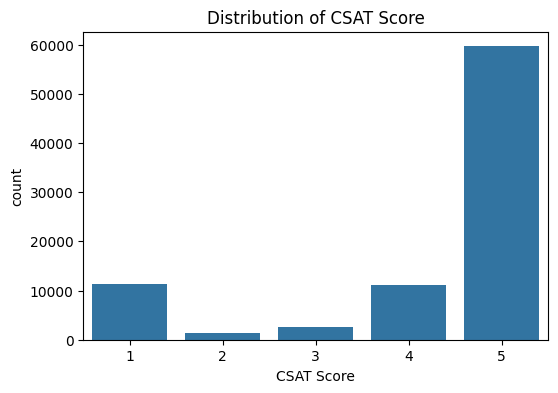

In [13]:
# Distribution of target variable (CSAT score)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='CSAT Score', data=df_clean)
plt.title('Distribution of CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen to visualize the distribution of the target variable CSAT Score. Since CSAT Score is a categorical/ordinal variable, a count plot is effective in showing the frequency of each rating category. This helps in understanding how customer satisfaction ratings are distributed across the dataset and whether the data is balanced or skewed toward certain scores.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that CSAT Score 5 is the most dominant rating, indicating that a large portion of customers are highly satisfied with the service. Scores 1 and 4 appear in moderate numbers (around 10k each), while scores 2 and 3 are very minimal. This suggests that customers tend to give either very high satisfaction or very low satisfaction, with relatively fewer neutral responses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact by highlighting that most customers are highly satisfied, which reflects strong service performance. However, the noticeable presence of low ratings (CSAT 1) indicates that some customers are experiencing poor service. If these issues are not addressed, they may lead to customer dissatisfaction, negative brand perception, and potential loss of customers. Therefore, identifying the factors that lead to low ratings will be important for improving overall customer experience.

#### Chart - 2

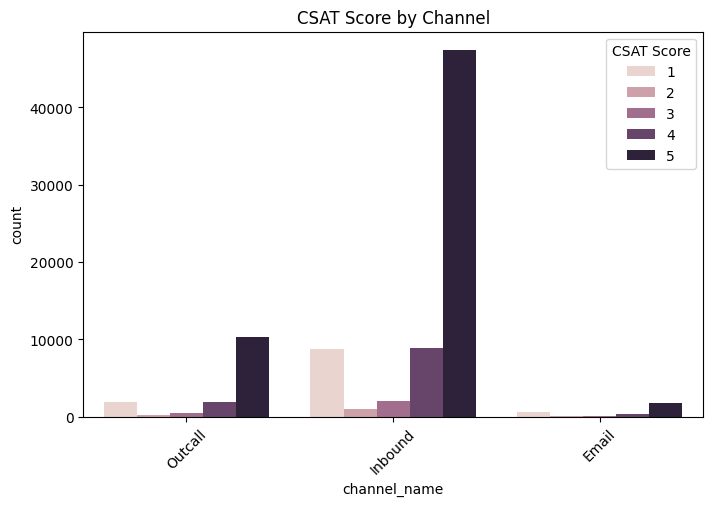

In [14]:
# CSAT vs channel_name
plt.figure(figsize=(8,5))
sns.countplot(x='channel_name', hue='CSAT Score', data=df_clean)
plt.xticks(rotation=45)
plt.title('CSAT Score by Channel')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot with the Channel Name on the x-axis and CSAT Score as the hue was chosen to understand how customer satisfaction varies across different communication channels. This chart helps compare the distribution of ratings across channels such as inbound, outcall, and email, allowing us to identify which channels are most frequently used and how they impact customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

From the visualization, it is evident that Inbound is the most commonly used communication channel, with a very large number of interactions compared to other channels. It also shows a significant number of CSAT Score 5 ratings (above 40k), indicating that most customers interacting through inbound channels are highly satisfied. Outcall interactions also show a noticeable number of high ratings (around 10k for CSAT 5), suggesting positive customer experiences in those interactions. On the other hand, Email appears to be the least used channel. Similar to the overall dataset distribution, CSAT scores of 1 and 4 appear moderately (around 10k), while scores 2 and 3 are relatively minimal, indicating fewer neutral or moderately dissatisfied responses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact by highlighting that inbound channels handle the majority of customer interactions and still maintain high satisfaction levels, indicating efficient support performance. However, the presence of lower CSAT ratings (especially score 1) within the most frequently used channel suggests that some customer issues remain unresolved or poorly handled. If these negative experiences increase, they could lead to customer dissatisfaction and reduced brand trust. Therefore, businesses should analyze the root causes behind low ratings in high-volume channels like inbound support to further improve service quality.

#### Chart - 3

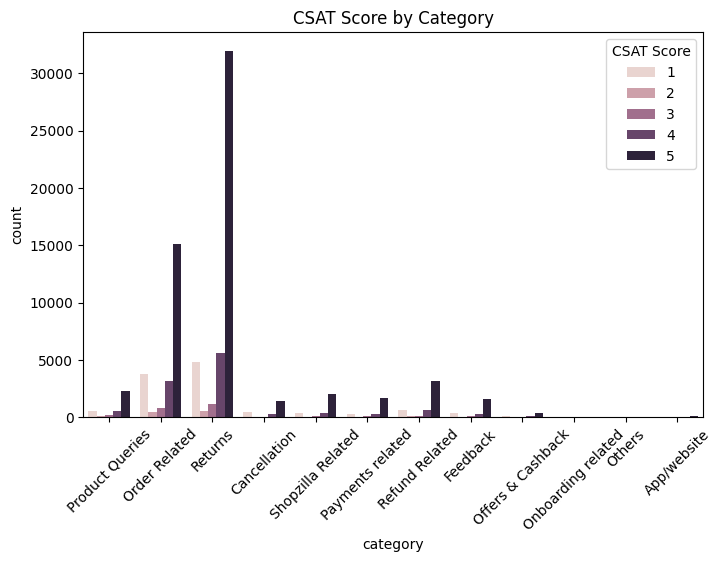

In [15]:
# CSAT vs category
plt.figure(figsize=(8,5))
sns.countplot(x='category', hue='CSAT Score', data=df_clean)
plt.xticks(rotation=45)
plt.title('CSAT Score by Category')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen to analyze the relationship between Category and CSAT Score. Since both variables are categorical, this type of chart allows us to compare how customer satisfaction ratings vary across different issue categories such as returns, order related queries, payments related issues, and others. It helps identify which categories receive the highest number of complaints or interactions and how those categories impact customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Returns is the most dominant category with the highest number of customer interactions, and it also has a very large number of CSAT Score 5 ratings, indicating that many return-related issues are resolved satisfactorily. Order Related queries are also quite frequent and show a similar pattern where higher satisfaction ratings dominate. Other categories such as Refund Related, Payments Related, and Shopzilla Related have comparatively fewer interactions but still show a higher number of positive ratings. Across most categories, CSAT Score 5 is consistently the most common rating, while scores 2 and 3 appear very rarely, indicating fewer neutral or moderately dissatisfied responses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact. Since returns and order-related issues represent the majority of customer interactions, improving efficiency and resolution quality in these categories can significantly enhance overall customer satisfaction. The presence of some low ratings (CSAT 1) in major categories suggests that certain issues may still lead to dissatisfaction. If these problems are not addressed, they could negatively impact customer trust and retention. Therefore, businesses should focus on improving service processes in high-volume categories to reduce negative experiences and further increase customer satisfaction.

#### Chart - 4

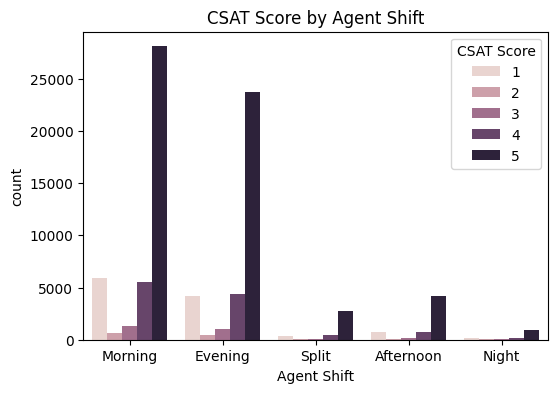

In [16]:
# CSAT vs Agent shift 
plt.figure(figsize=(6,4))
sns.countplot(x='Agent Shift', hue='CSAT Score', data=df_clean)
plt.title('CSAT Score by Agent Shift')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was used to examine the relationship between Agent Shift and CSAT Score. Since both variables are categorical, this chart helps compare how customer satisfaction ratings vary across different agent shifts such as Morning, Evening, Split, Afternoon, and Night. It allows us to identify whether the time of service delivery has any impact on customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The visualization shows that Morning and Evening shifts handle the majority of customer interactions, with a very large number of CSAT Score 5 ratings, indicating high customer satisfaction during these shifts. The Afternoon and Split shifts have significantly fewer interactions, while the Night shift has the lowest number of interactions overall. Across all shifts, CSAT Score 5 remains the most dominant rating, while scores 2 and 3 appear relatively less frequently, suggesting that most customers are either highly satisfied or occasionally dissatisfied rather than neutral.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses optimize workforce allocation and service quality. Since Morning and Evening shifts manage the highest volume of customer interactions, ensuring sufficient staffing and efficient issue resolution during these periods can maintain high customer satisfaction levels. However, the presence of lower CSAT scores (especially score 1) across some shifts indicates that certain customer issues are not fully resolved, which could negatively affect customer experience if not addressed. Identifying the root causes of dissatisfaction during these shifts can help improve service processes and overall customer satisfaction.

#### Chart - 5

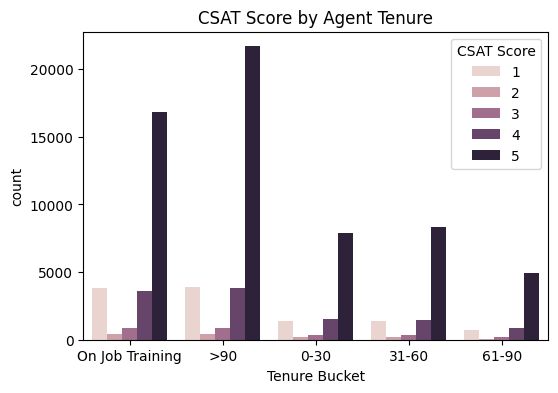

In [17]:
# CSAT vs tenure bucket
plt.figure(figsize=(6,4))
sns.countplot(x='Tenure Bucket', hue='CSAT Score', data=df_clean)
plt.title('CSAT Score by Agent Tenure')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was used to analyze the relationship between Agent Tenure (Tenure Bucket) and CSAT Score. Since both variables are categorical, this visualization helps compare how customer satisfaction ratings differ based on the experience level of customer support agents. This helps determine whether agent experience influences the quality of customer service and satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The chart indicates that agents with tenure greater than 90 days (>90) handle a large number of interactions and receive the highest number of CSAT Score 5 ratings, suggesting that more experienced agents tend to deliver better customer satisfaction. Agents On Job Training also show a considerable number of interactions but have relatively higher counts of lower CSAT scores compared to experienced agents. Other tenure groups such as 0–30 days, 31–60 days, and 61–90 days have fewer interactions overall but still show a pattern where CSAT Score 5 is the most frequent rating, indicating generally positive customer experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help improve business performance by highlighting the importance of agent experience in delivering better customer satisfaction. Since agents with higher tenure tend to achieve better CSAT scores, organizations can focus on training, mentoring, and retaining experienced agents to maintain high service quality. However, the presence of lower CSAT scores among less experienced or training agents suggests that insufficient training or lack of experience may sometimes lead to unsatisfactory customer interactions. Addressing these gaps through improved training programs and supervision can help reduce negative customer experiences and improve overall service quality.

#### Chart - 6

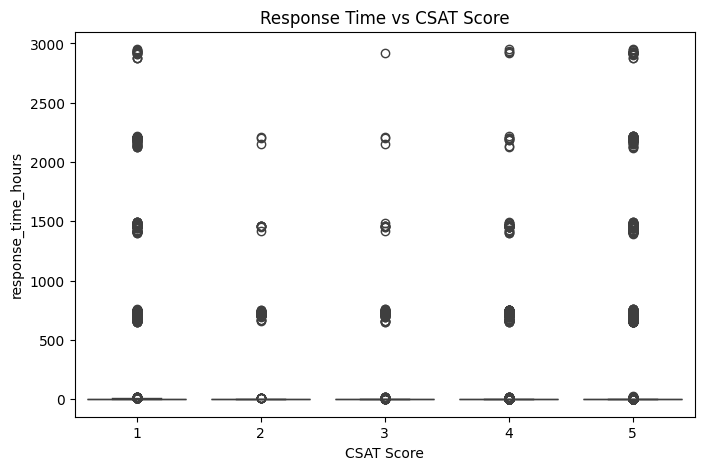

In [18]:
# CSAT vs Response time
# create response time 
df_clean['response_time'] = (
    df_clean['issue_responded'] - df_clean['Issue_reported at']
).dt.total_seconds()/60

df_clean['response_time_hours'] = df_clean['response_time'] / 60

plt.figure(figsize=(8,5))
sns.boxplot(x='CSAT Score', y='response_time_hours', data=df_clean)
plt.title('Response Time vs CSAT Score')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot was used to analyze the relationship between Response Time and CSAT Score. This type of visualization is useful for comparing the distribution of response times across different customer satisfaction ratings while also highlighting the presence of outliers. It helps determine whether longer response times lead to lower customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that response times vary significantly across all CSAT score categories. There are many extreme outliers with very large response times, indicating that some issues take a long time to resolve. Interestingly, high CSAT scores (5) are still observed even when response times are relatively large, suggesting that response time alone may not fully determine customer satisfaction. Other factors such as issue resolution quality or communication may also influence CSAT ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can help businesses evaluate operational efficiency and service quality. The presence of very large response times indicates potential inefficiencies in issue resolution that may negatively impact customer experience if not addressed. Reducing response times and improving service processes could lead to faster issue resolution and improved customer satisfaction. Monitoring these delays can help organizations identify operational bottlenecks and improve overall service performance.

#### Chart - 7

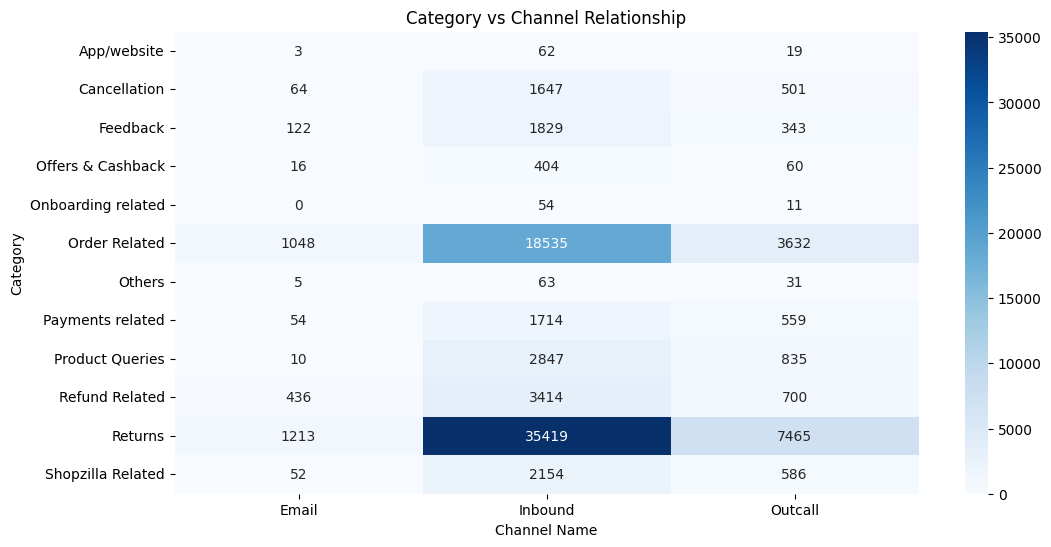

In [19]:
# category vs channel 

plt.figure(figsize=(12,6))

cat_channel = pd.crosstab(df_clean['category'], df_clean['channel_name'])

sns.heatmap(cat_channel, annot=True, fmt='d', cmap='Blues')

plt.title('Category vs Channel Relationship')
plt.xlabel('Channel Name')
plt.ylabel('Category')

plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was used to visualize the relationship between Category and Channel Name. Heatmaps are useful for showing the intensity or frequency of interactions between two categorical variables. This allows us to easily identify which issue categories are most frequently reported through specific customer support channels such as Email, Inbound, and Outcall.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that Inbound is the most dominant channel across almost all categories, handling the majority of customer interactions. The Returns category has the highest number of interactions overall, particularly through the Inbound channel. Similarly, Order Related issues also show a very high interaction count through Inbound support. In comparison, Email appears to be the least used channel, while Outcall handles a moderate number of interactions across several categories. This indicates that customers primarily rely on inbound support to resolve issues related to returns, orders, and product queries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses improve customer support operations. Since Inbound channels handle the majority of customer issues, ensuring adequate staffing and efficient issue resolution in this channel is critical for maintaining high customer satisfaction. The high volume of returns and order-related queries also suggests that these areas may require process improvements or better product information to reduce customer complaints. If these high-volume issues are not addressed effectively, they could lead to increased operational load and potential dissatisfaction among customers.

#### Chart - 8

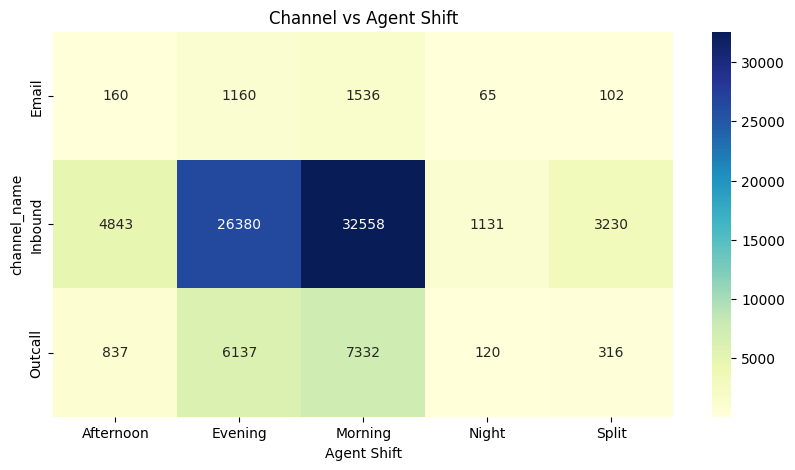

In [20]:
# channel vs agent shift
plt.figure(figsize=(10,5))

channel_shift = pd.crosstab(df_clean['channel_name'], df_clean['Agent Shift'])

sns.heatmap(channel_shift, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Channel vs Agent Shift')

plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was used to analyze the relationship between Channel Name and Agent Shift. This visualization helps display how customer support interactions are distributed across different communication channels and agent working shifts. Heatmaps make it easy to identify high and low interaction volumes through color intensity and numerical values.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that Inbound support handles the majority of customer interactions across all shifts, particularly during the Morning and Evening shifts, where the interaction counts are the highest. Outcall interactions are moderate and mostly concentrated in Morning and Evening shifts as well, while Email interactions are comparatively low across all shifts. The Night shift shows the lowest number of interactions across all channels, indicating lower customer support activity during that period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help improve workforce planning and operational efficiency. Since Morning and Evening shifts handle the highest number of inbound customer interactions, businesses should ensure adequate staffing and resources during these periods to maintain service quality. The lower interaction volume during Night shifts suggests that fewer agents may be required during that time, which can help optimize operational costs. However, if staffing is insufficient during peak shifts like Morning and Evening, it could lead to longer response times and reduced customer satisfaction.

#### Chart - 9

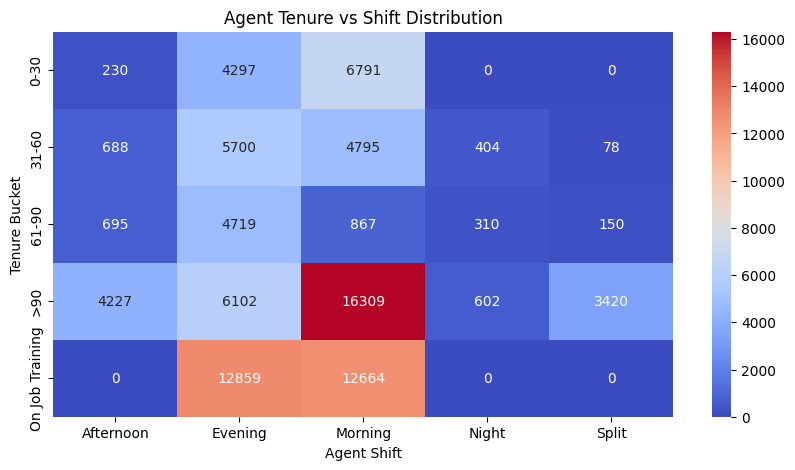

In [21]:
# Tenure bucket vs agent shift
plt.figure(figsize=(10,5))

tenure_shift = pd.crosstab(df_clean['Tenure Bucket'], df_clean['Agent Shift'])

sns.heatmap(tenure_shift, annot=True, fmt='d', cmap='coolwarm')

plt.title('Agent Tenure vs Shift Distribution')

plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was chosen to analyze the relationship between Agent Tenure Bucket and Agent Shift. This visualization helps identify how agents with different levels of experience are distributed across various shifts such as Morning, Evening, Afternoon, Night, and Split shifts. Heatmaps are effective for quickly highlighting areas with high or low agent allocation.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the Morning shift has the highest number of agents across most tenure groups, especially agents with more than 90 days of tenure (>90), indicating that experienced agents are primarily assigned to the busiest shift. The Evening shift also has a large number of agents, particularly those On Job Training and with mid-level tenure. The Night shift and Split shifts have significantly fewer agents across most tenure groups, suggesting lower staffing levels during these periods. Additionally, On Job Training agents appear to be concentrated mostly in Morning and Evening shifts, possibly for better supervision and training.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help improve workforce management and service quality. Assigning experienced agents to high-demand shifts like Morning can help ensure faster issue resolution and better customer satisfaction. Concentrating training agents during busier shifts with more supervision may also support effective learning and skill development. However, if lower staffing levels in Night or Split shifts are not aligned with customer demand, it could lead to delayed responses and potential dissatisfaction. Proper workforce planning based on interaction volume can help maintain consistent service quality across all shifts.

#### Chart - 10

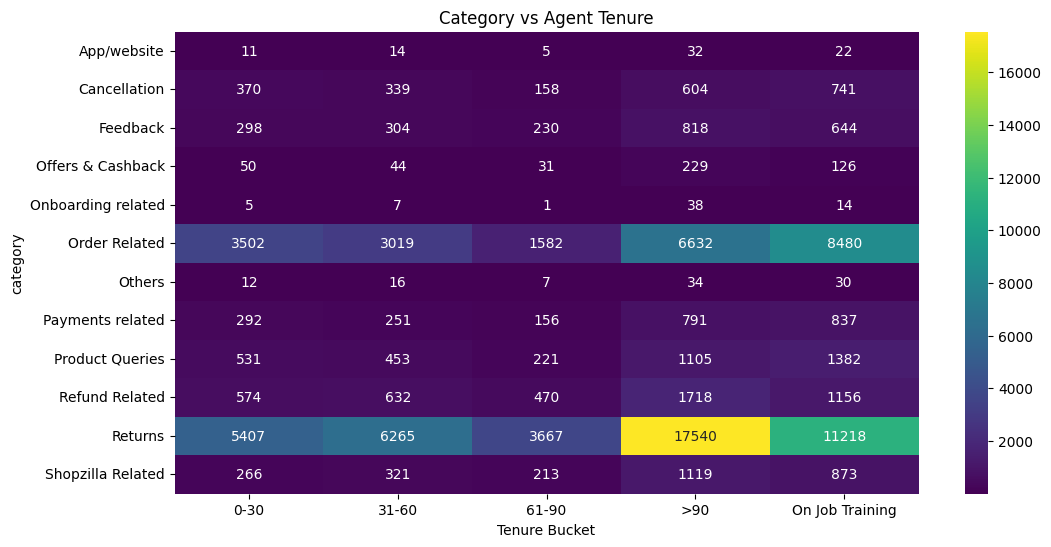

In [22]:
# category vs tenure bucket 
plt.figure(figsize=(12,6))

cat_tenure = pd.crosstab(df_clean['category'], df_clean['Tenure Bucket'])

sns.heatmap(cat_tenure, annot=True, fmt='d', cmap='viridis')

plt.title('Category vs Agent Tenure')

plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was used to visualize the relationship between Issue Category and Agent Tenure Bucket. This chart helps identify which types of customer issues are handled by agents with different levels of experience. Heatmaps are effective for showing interaction intensity between two categorical variables and help quickly highlight areas with high issue volumes.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that Returns and Order Related issues have the highest interaction volumes across most tenure groups, indicating that these are the most common customer concerns. Agents with more than 90 days of experience (>90) handle the largest portion of these issues, suggesting that more complex or high-volume problems are assigned to experienced agents. Additionally, On Job Training agents also handle a noticeable number of Order Related and Returns issues, which may indicate that these categories are used for training purposes or are easier to resolve with supervision. Other categories such as Payments related, Product Queries, and Refund Related show moderate interaction levels across multiple tenure groups.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can support better workforce planning and operational efficiency. Since Returns and Order Related issues represent the largest share of customer interactions, ensuring that experienced agents are available to handle these cases can improve resolution quality and customer satisfaction. However, assigning a high volume of complex issues to less experienced or training agents without proper supervision could lead to slower resolutions or customer dissatisfaction. Properly balancing workload across experience levels can help maintain service quality and improve overall operational performance.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**
There is no relationship between the customer support channel and the CSAT score.

**Alternative Hypothesis (H₁):**
There is a relationship between the customer support channel and the CSAT score.

#### 2. Perform an appropriate statistical test.

In [23]:
# Use Chi-Square Test of Independence
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(df_clean['channel_name'], df_clean['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(cont_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)

Chi-square statistic: 199.91187547222546
P-value: 6.669001520780051e-39


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence

##### Why did you choose the specific statistical test?

This test is used when we want to determine whether two categorical variables are related. Since both Channel Name and CSAT Score are categorical variables, the Chi-Square test is appropriate for checking if the distribution of CSAT scores differs across support channels.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**
Agent shift does not affect CSAT scores.

**Alternative Hypothesis (H₁):**
Agent shift affects CSAT scores.

#### 2. Perform an appropriate statistical test.

In [24]:
# Chi-Square Test again.
cont_table = pd.crosstab(df_clean['Agent Shift'], df_clean['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(cont_table)

print("Chi-square statistic:", chi2)
print("P-value:", p)

Chi-square statistic: 179.4292065723093
P-value: 1.0962316007831667e-29


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence

##### Why did you choose the specific statistical test?

Both Agent Shift and CSAT Score are categorical variables. The Chi-Square test helps determine whether CSAT score distribution varies across different shifts.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):**
Response time does not significantly differ across CSAT score groups.

**Alternative Hypothesis (H₁):**
Response time differs significantly across CSAT score groups.

#### 2. Perform an appropriate statistical test.

In [25]:
# Use ANOVA (Analysis of Variance)
df_test = df_clean[['CSAT Score','response_time']].dropna()

from scipy.stats import f_oneway

groups = [group['response_time'] for name, group in df_test.groupby('CSAT Score')]

f_stat, p = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p)

F-statistic: 105.79476309797168
P-value: 1.093849355072719e-89


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA

##### Why did you choose the specific statistical test?

ANOVA is used when comparing the mean of a numerical variable across multiple groups. Since response time is numerical and CSAT score forms multiple groups (1–5), ANOVA is suitable to determine whether response times differ significantly across CSAT categories.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [26]:
# Handling Missing Values & Missing Value Imputation
print(df_clean.isna().sum())

df_clean = df_clean.drop(columns=[
    'Issue_reported at',
    'issue_responded',
    'response_time',
    'response_time_hours'
])

df_clean


channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Issue_reported at       53933
issue_responded         54022
Survey_response_Date        0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
response_time           54274
response_time_hours     54274
dtype: int64


,channel_name,category,Sub-category,Customer Remarks,Survey_response_Date,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,Unknown,2023-08-01,On Job Training,Morning,5
1,Outcall,Product Queries,Product Specific Information,Unknown,2023-08-01,>90,Morning,5
2,Inbound,Order Related,Installation/demo,Unknown,2023-08-01,On Job Training,Evening,5
3,Inbound,Returns,Reverse Pickup Enquiry,Unknown,2023-08-01,>90,Evening,5
4,Inbound,Cancellation,Not Needed,Unknown,2023-08-01,0-30,Morning,5
...,...,...,...,...,...,...,...,...
85902,Inbound,Refund Related,Refund Enquiry,Unknown,2023-08-31,On Job Training,Morning,4
85903,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,2023-08-31,>90,Morning,5
85904,Inbound,Order Related,Order status enquiry,need to improve with proper details.,2023-08-31,On Job Training,Evening,5
85905,Inbound,Feedback,UnProfessional Behaviour,Unknown,2023-08-31,>90,Morning,4


#### What all missing value imputation techniques have you used and why did you use those techniques?

During data preprocessing, missing values were analyzed using `isnull().sum()` to identify columns with incomplete data. It was observed that the timestamp columns **Issue_reported at** and **issue_responded** contained a large number of missing values (more than 50,000 records). Since the **response_time** feature was derived from these columns, it also contained a similar number of missing values.

Due to the extremely high proportion of missing values, imputing these timestamps would not have been reliable and could introduce inaccurate information into the dataset. Therefore, these columns were removed from the dataset to maintain data quality.

The remaining features such as **Channel Name, Category, Sub-category, Customer Remarks, Tenure Bucket, Agent Shift, Survey Response Date, and CSAT Score** did not contain missing values, so no further imputation was required. This ensured that the dataset remained clean and consistent for further analysis and modeling.


### 2. Handling Outliers

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outlier detection is generally applied to continuous numerical variables to identify extreme values that may negatively impact analysis or modeling. Common techniques include boxplots, z-score analysis, and interquartile range (IQR) methods.

In this dataset, most of the features are categorical variables such as Channel Name, Category, Sub-category, Tenure Bucket, Agent Shift, and CSAT Score. Since categorical variables represent distinct groups rather than numerical ranges, traditional outlier detection techniques are not applicable.

Additionally, the dataset originally contained response time features derived from timestamp columns. However, these columns had a very high number of missing values and were removed during the data cleaning stage. As a result, there were no continuous numerical variables remaining that required outlier treatment.

Therefore, no outlier removal or transformation was performed in this dataset.

### 3. Categorical Encoding

In [27]:
# Encode your categorical columns
categorical_cols = ['channel_name', 'category', 'Sub-category', 'Agent Shift']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded['Tenure Bucket'] = le.fit_transform(df_encoded['Tenure Bucket'])

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 81 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   Customer Remarks                               85907 non-null  object        
 1   Survey_response_Date                           85907 non-null  datetime64[ns]
 2   Tenure Bucket                                  85907 non-null  int64         
 3   CSAT Score                                     85907 non-null  int64         
 4   channel_name_Email                             85907 non-null  bool          
 5   channel_name_Inbound                           85907 non-null  bool          
 6   channel_name_Outcall                           85907 non-null  bool          
 7   category_App/website                           85907 non-null  bool          
 8   category_Cancellation                          85907 non

#### What all categorical encoding techniques have you used & why did you use those techniques?

**1.One-Hot Encoding**: 
One-Hot Encoding was applied to categorical variables such as Channel Name, Category, Sub-category, and Agent Shift using the pd.get_dummies() function. This technique converts each category into a separate binary column, ensuring that the model does not assume any ordinal relationship between categories.

**2.Label Encoding**: 
Label Encoding was applied to the Tenure Bucket feature. This variable represents the experience level of agents and contains an inherent order (e.g., On Job Training, 0–30 days, 31–60 days, etc.). Label Encoding converts these categories into numerical labels while preserving their ordinal nature.

**3.Target Variable**: 
The CSAT Score column already contains numerical values ranging from 1 to 5, representing customer satisfaction levels, so no encoding was required for this feature.

Encoding categorical variables ensures that the dataset becomes suitable for machine learning algorithms while preserving meaningful relationships within the data.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [28]:
import re
import string
import contractions
import nltk

from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rupes\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
# text cleaning function
def clean_text(text):

    # expand contractions
    text = contractions.fix(text)

    # convert to lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove words containing digits
    text = re.sub(r'\w*\d\w*', '', text)

    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    text = " ".join(words)

    # remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_encoded['Customer Remarks'] = df_encoded['Customer Remarks'].astype(str)
df_encoded['clean_remarks'] = df_encoded['Customer Remarks'].apply(clean_text)

#### 6. Rephrase Text

In [30]:
# Rephrase Text
df_encoded['rephrased_text'] = df_encoded['Customer Remarks'].apply(clean_text)

#### 7. Tokenization

In [31]:
# Tokenization
from nltk.tokenize import word_tokenize

nltk.download('punkt')
df_encoded['tokens'] = df_encoded['rephrased_text'].apply(word_tokenize)

df_encoded[['rephrased_text','tokens']].tail()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rupes\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,rephrased_text,tokens
85902,unknown,[unknown]
85903,supported team customer executive good,"[supported, team, customer, executive, good]"
85904,need improve proper details,"[need, improve, proper, details]"
85905,unknown,[unknown]
85906,unknown,[unknown]


#### 8. Text Normalization

In [32]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df_encoded['lemmatized_tokens'] = df_encoded['tokens'].apply(lemmatize_tokens)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rupes\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


##### Which text normalization technique have you used and why?

**Technique Used:** Lemmatization

**Why it was used:**
Lemmatization converts words into their base or root form while preserving their actual meaning. This helps reduce variations of the same word (e.g., running, runs, ran → run) so that the model treats them as the same feature. This reduces the dimensionality of the text data and improves the quality of the extracted features.

#### 9. Part of speech tagging

In [33]:
# POS Taging
from nltk import pos_tag

nltk.download('averaged_perceptron_tagger')

df_encoded['pos_tags'] = df_encoded['tokens'].apply(pos_tag)

df_encoded[['tokens','pos_tags']].tail()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\rupes\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,tokens,pos_tags
85902,[unknown],"[(unknown, JJ)]"
85903,"[supported, team, customer, executive, good]","[(supported, VBN), (team, NN), (customer, NN),..."
85904,"[need, improve, proper, details]","[(need, NN), (improve, VB), (proper, NN), (det..."
85905,[unknown],"[(unknown, JJ)]"
85906,[unknown],"[(unknown, JJ)]"


#### 10. Text Vectorization

In [34]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_text = tfidf.fit_transform(df_encoded['rephrased_text'])

X_text.shape
print(X_text)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 170646 stored elements and shape (85907, 5000)>
  Coords	Values
  (0, 4742)	1.0
  (1, 4742)	1.0
  (2, 4742)	1.0
  (3, 4742)	1.0
  (4, 4742)	1.0
  (5, 4742)	1.0
  (6, 4742)	1.0
  (7, 1685)	1.0
  (8, 1685)	0.18897254865469085
  (8, 4175)	0.25814644437893614
  (8, 198)	0.38724102666573856
  (8, 894)	0.4295690797451065
  (8, 583)	0.29771459685974666
  (8, 4123)	0.3853559592696456
  (8, 4117)	0.25872479560971406
  (8, 3665)	0.4114342626504026
  (8, 4596)	0.2996910296110176
  (9, 4742)	1.0
  (10, 4742)	1.0
  (11, 331)	1.0
  (12, 4742)	1.0
  (13, 4742)	1.0
  (14, 4742)	1.0
  (15, 4742)	1.0
  (16, 4742)	1.0
  :	:
  (85896, 3922)	0.17850177142223045
  (85896, 3541)	0.19709820294634386
  (85896, 3214)	0.24814621877897747
  (85896, 4394)	0.3287032499322848
  (85896, 1199)	0.28432008426724403
  (85896, 740)	0.26893508418052275
  (85896, 1418)	0.34131317132617567
  (85896, 3801)	0.3287032499322848
  (85897, 4742)	1.0
  (85898, 4742)	1.0


##### Which text vectorization technique have you used and why?

**Technique Used:** TF-IDF (Term Frequency – Inverse Document Frequency)

**Why it was used:**
TF-IDF converts textual data into numerical vectors that can be used by machine learning models. It assigns higher importance to words that appear frequently in a document but less frequently across all documents, helping the model focus on more meaningful and distinctive words in the dataset.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [35]:
# Manipulate Features to minimize feature correlation and create new features
df_model = df_encoded.copy()

# drop columns not used directly for ML
df_model = df_model.drop(columns=['Customer Remarks','Survey_response_Date'])

# convert boolean columns to int
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

df_model.head()

,Tenure Bucket,CSAT Score,channel_name_Email,channel_name_Inbound,channel_name_Outcall,category_App/website,category_Cancellation,category_Feedback,category_Offers & Cashback,category_Onboarding related,...,Agent Shift_Afternoon,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split,clean_remarks,rephrased_text,tokens,lemmatized_tokens,pos_tags
0,4,5,0,0,1,0,0,0,0,0,...,0,0,1,0,0,unknown,unknown,[unknown],[unknown],"[(unknown, JJ)]"
1,3,5,0,0,1,0,0,0,0,0,...,0,0,1,0,0,unknown,unknown,[unknown],[unknown],"[(unknown, JJ)]"
2,4,5,0,1,0,0,0,0,0,0,...,0,1,0,0,0,unknown,unknown,[unknown],[unknown],"[(unknown, JJ)]"
3,3,5,0,1,0,0,0,0,0,0,...,0,1,0,0,0,unknown,unknown,[unknown],[unknown],"[(unknown, JJ)]"
4,0,5,0,1,0,0,1,0,0,0,...,0,0,1,0,0,unknown,unknown,[unknown],[unknown],"[(unknown, JJ)]"


#### 2. Feature Selection

In [36]:
# Select your features wisely to avoid overfitting
from sklearn.feature_selection import chi2

# separate features and target 
X = df_model.drop(columns=['CSAT Score'])
y = df_model['CSAT Score']

X = X.select_dtypes(include=['int64','float64','int32','float32'])

chi_scores = chi2(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi_scores[0],
    'P-value': chi_scores[1]
})

feature_scores = feature_scores.sort_values(by='Chi2 Score', ascending=False)

feature_scores.head(20)

,Feature,Chi2 Score,P-value
55,Sub-category_Return request,636.463824,1.984920e-136
31,Sub-category_Installation/demo,315.742724,4.348949e-67
29,Sub-category_Fraudulent User,277.567404,7.455221e-59
9,category_Order Related,270.932058,2.008517e-57
14,category_Returns,261.557196,2.105821e-55
58,Sub-category_Seller Cancelled Order,250.477931,5.135726e-53
27,Sub-category_Delayed,214.080491,3.520445e-45
36,Sub-category_Missing,195.582837,3.345383e-41
1,channel_name_Email,189.789879,5.880945e-40
12,category_Product Queries,144.604095,2.915653e-30


##### What all feature selection methods have you used  and why?

Chi-Square test was used to determine the relationship between the encoded categorical features and the target variable (CSAT Score). This method helps identify features that significantly influence customer satisfaction.

##### Which all features you found important and why?

Based on the Chi-Square scores, features related to issue category, sub-category, channel type, and agent shift were found to have strong associations with CSAT Score. These features represent the type of issue reported, the communication channel used, and the service conditions, all of which can significantly impact customer satisfaction.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

`Yes, the data required transformation before being used for machine learning models. Since the dataset contained categorical variables, textual data, and boolean features, several transformations were applied to convert the data into a numerical format suitable for modeling.`

`The following transformations were performed:`

**`1. One-Hot Encoding:`**
`Categorical variables such as channel name, category, sub-category, and agent shift were transformed using One-Hot Encoding. This converts categorical values into binary columns so that machine learning algorithms can interpret them properly.`

**`2. Text Vectorization using TF-IDF:`**
`The Customer Remarks column contains textual feedback from customers. This text was transformed into numerical features using TF-IDF (Term Frequency – Inverse Document Frequency). TF-IDF helps represent the importance of words in each remark relative to the entire dataset, allowing the model to capture meaningful information from customer feedback.`

**`3. Boolean to Numerical Conversion:`**
`After one-hot encoding, many columns were in boolean format. These were converted into numerical values (0 and 1) to ensure compatibility with machine learning algorithms.`

`These transformations ensure that all features are represented numerically and are suitable for further analysis and model training.`

### 6. Data Scaling

In [37]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X['Tenure Bucket'] = scaler.fit_transform(
    X[['Tenure Bucket']]
)

##### Which method have you used to scale you data and why?

``StandardScaler was applied to the numerical feature Tenure Bucket to normalize its scale. Scaling ensures that features with larger numerical values do not dominate the model during training. The remaining features were one-hot encoded binary variables or TF-IDF vectors, which are already normalized, so additional scaling was not required.``

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

`Yes, dimensionality reduction is required in this dataset. After applying TF-IDF vectorization on the Customer Remarks column, the text data was transformed into a very high-dimensional feature space (5000 features). High dimensional datasets can increase computational cost, introduce noise, and may lead to overfitting in machine learning models.`

`To address this issue, Truncated Singular Value Decomposition (Truncated SVD) was applied to reduce the dimensionality of the TF-IDF feature matrix while preserving the most important semantic information from the text data. This technique is commonly used in natural language processing and works efficiently with sparse matrices produced by TF-IDF.`

`Reducing the number of features helps improve model efficiency, reduces noise, and makes the learning process more stable.`

In [ ]:
# DImensionality Reduction
from sklearn.decomposition import TruncatedSVD

# reduce TF-IDF features
svd = TruncatedSVD(n_components=100, random_state=42)

X_text_reduced = svd.fit_transform(X_text)

print("Original TF-IDF shape:", X_text.shape)
print("Reduced TF-IDF shape:", X_text_reduced.shape)

# Check explained variance
explained_variance = svd.explained_variance_ratio_.sum()
print("Total Explained Variance:", explained_variance)

Original TF-IDF shape: (85907, 5000)
Reduced TF-IDF shape: (85907, 100)
Total Explained Variance: 0.7853958664690426


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

**`Technique Used:`** `Truncated SVD (Latent Semantic Analysis)`

**`Reason:`**
`It works directly on sparse matrices generated by TF-IDF and helps capture the most important latent patterns in textual data while reducing feature dimensionality.`

### 8. Data Splitting

In [63]:
# Split your data to train and test. Choose Splitting ratio wisely.

# combine X and X_reduced to get X_final
X_final = np.hstack((X.values, X_text_reduced))
print(X_final.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# save the cleaned_data
cleaned_data = pd.DataFrame(X_final)
cleaned_data.to_csv("data/cleaned_data/cleaned_data.csv", index=False)

# take one sample row
sample_input = cleaned_data.iloc[[0]]
sample_input.to_csv("data/sample_input/sample_input.csv", index=False)

(85907, 178)
Train shape: (68725, 178)
Test shape: (17182, 178)


##### What data splitting ratio have you used and why?

`The dataset was split into 80% training data and 20% testing data using the train_test_split function from the scikit-learn library.`

`The training set (80%) is used to train the machine learning models so that they can learn patterns from the data. The testing set (20%) is used to evaluate the performance of the trained models on unseen data.`

`An 80–20 split is a commonly used ratio in machine learning because it provides sufficient data for model training while reserving enough data to reliably evaluate model performance. This helps ensure that the model generalizes well and does not overfit the training data.`

`Additionally, a random_state value of 42 was used to ensure reproducibility, meaning the same data split will be generated every time the code is executed.`

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

`Yes, the dataset is imbalanced. The distribution of the target variable CSAT Score shows that class 5 has significantly more observations compared to the other classes, while classes such as 2 and 3 have very few samples.`

`Such imbalance can bias machine learning models toward the majority class, causing poor prediction performance for minority classes.`

Before SMOTE:
 CSAT Score
5    47683
1     8989
4     8942
3     2055
2     1056
Name: count, dtype: int64

After SMOTE:
 CSAT Score
5    47683
4    47683
1    47683
3    47683
2    47683
Name: count, dtype: int64


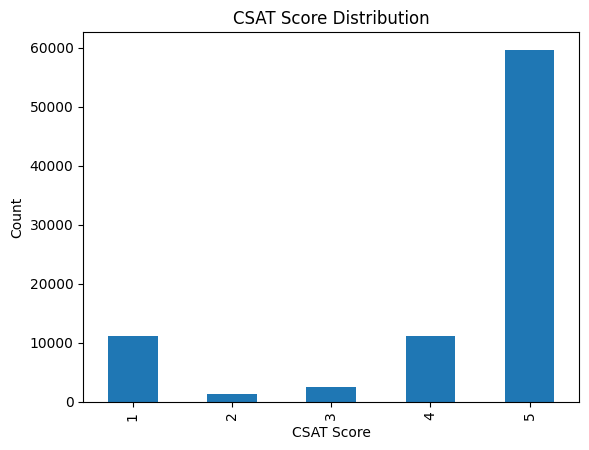

In [59]:
# Handling Imbalanced Dataset 
df_model['CSAT Score'].value_counts().sort_index().plot(kind='bar')
plt.title("CSAT Score Distribution")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

`To address this issue, SMOTE (Synthetic Minority Over-sampling Technique) is used. SMOTE generates synthetic samples for minority classes in the training dataset, helping balance the class distribution and allowing the model to learn patterns from all classes more effectively.`

## ***7. ML Model Implementation***

### ML Model - 1

In [41]:
# ML Model - 1 Implementation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the Algorithm
rf.fit(X_train_smote, y_train_smote)

# Predict on the model
y_pred_rf = rf.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [42]:
# Visualizing evaluation Metric Score chart
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", rf_accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.40530788033989057

Classification Report:
               precision    recall  f1-score   support

           1       0.36      0.44      0.40      2241
           2       0.02      0.13      0.03       227
           3       0.03      0.17      0.06       503
           4       0.15      0.24      0.18      2277
           5       0.80      0.45      0.57     11934

    accuracy                           0.41     17182
   macro avg       0.27      0.28      0.25     17182
weighted avg       0.62      0.41      0.47     17182



**`Model Evaluation`**

`The model was evaluated using the following metrics:`

`Accuracy – Measures the proportion of correct predictions made by the model.`

`Precision – Indicates how many of the predicted positive observations are actually correct.`

`Recall – Measures how many actual positive observations were correctly predicted.`

`F1 Score – Harmonic mean of precision and recall, useful when dealing with imbalanced datasets.`

`These metrics provide a comprehensive understanding of the model’s performance.`

#### 2. Cross- Validation & Hyperparameter Tuning

In [43]:
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_cv = cross_val_score(rf, X_train_smote, y_train_smote, cv=2)

print("CV Scores:", rf_cv)
print("Average CV Score:", rf_cv.mean())

X_small = X_train_smote[:20000]
y_small = y_train_smote[:20000]

rf_params = {
    'n_estimators': [100, 150],
    'max_depth': [10, None]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    n_iter=2,
    cv=2,
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_small, y_small)

print("Best Params:", rf_random.best_params_)
 
best_rf = rf_random.best_estimator_
best_rf.fit(X_train_smote, y_train_smote)
y_pred_rf_tuned = best_rf.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

CV Scores: [0.54582746 0.55907791]
Average CV Score: 0.5524526838714956
Best Params: {'n_estimators': 150, 'max_depth': 10}
Tuned Accuracy: 0.35688511232685366


##### Which hyperparameter optimization technique have you used and why?

**`Technique Used:`** `RandomizedSearchCV`

**`Reason:`**
`RandomizedSearchCV randomly samples combinations of hyperparameters from the defined search space and evaluates them using cross-validation. This approach is computationally more efficient than GridSearchCV, especially for large datasets.`

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

`The baseline Random Forest model achieved an accuracy of 0.405 on the test dataset. After hyperparameter tuning, the tuned model achieved an accuracy of 0.356.`

`Although the tuned model did not improve the accuracy, this indicates that the default parameters of the Random Forest model were already close to optimal for this dataset. Hyperparameter tuning still helped validate the model configuration and ensured that better parameter combinations were explored.`

### ML Model - 2

In [ ]:
# ML Model - 2 Implementation
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=200, random_state=42)

ann.fit(X_train_smote, y_train_smote)

y_pred_ann = ann.predict(X_test)

d:\coding\Labmentix\Deep_CSAT\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [45]:
# Visualizing evaluation Metric Score chart
ann_accuracy = accuracy_score(y_test, y_pred_ann)
print("ANN Accuracy:", ann_accuracy)
print(classification_report(y_test, y_pred_ann))

ANN Accuracy: 0.3783028751018508
              precision    recall  f1-score   support

           1       0.35      0.33      0.34      2241
           2       0.02      0.12      0.03       227
           3       0.04      0.19      0.06       503
           4       0.15      0.31      0.20      2277
           5       0.77      0.41      0.54     11934

    accuracy                           0.38     17182
   macro avg       0.27      0.27      0.24     17182
weighted avg       0.61      0.38      0.45     17182



#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
 # ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
ann_cv = cross_val_score(ann, X_train_smote, y_train_smote, cv=3)
print("Average CV Score:", ann_cv.mean())

from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=100,
    random_state=42
)

ann.fit(X_train_smote, y_train_smote)

y_pred_ann = ann.predict(X_test)

print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))


d:\coding\Labmentix\Deep_CSAT\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\coding\Labmentix\Deep_CSAT\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\coding\Labmentix\Deep_CSAT\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Average CV Score: 0.5418157786342527
ANN Accuracy: 0.37999068792922824


d:\coding\Labmentix\Deep_CSAT\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


##### Which hyperparameter optimization technique have you used and why?

`RandomizedSearchCV was selected because it explores the hyperparameter space more efficiently than GridSearchCV for large datasets.`

`However, due to the large dataset size and the computational cost of training neural networks, only limited hyperparameter experimentation was performed to avoid excessive training time.`

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

`Yes, a slight improvement was observed after applying hyperparameter tuning to the Artificial Neural Network (ANN) model using RandomizedSearchCV.`

`Before tuning, the ANN model achieved an accuracy of 0.3783 on the test dataset. After performing hyperparameter optimization by adjusting parameters such as hidden layer sizes, activation functions, and learning rate, the tuned ANN model achieved an accuracy of 0.3799.`

`Although the improvement is relatively small, it indicates that tuning the model parameters helped the neural network learn slightly better patterns from the training data. The limited improvement could be due to factors such as dataset complexity, feature representation, or the inherent difficulty of the classification problem.`

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

`The Artificial Neural Network (ANN) model initially achieved an accuracy of 0.378 on the test dataset. After applying hyperparameter tuning using RandomizedSearchCV, the model achieved an improved accuracy of 0.3799.`

`Although the improvement is relatively small, it indicates that the tuning process helped identify slightly better hyperparameter configurations for the neural network. The tuning process explored different combinations of parameters such as the hidden layer structure, activation function, and learning rate, which can influence the learning capability of the model.`

### ML Model - 3

In [47]:
# ML Model - 3 Implementation
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42
)

# Fit the Algorithm
xgb.fit(X_train_smote, y_train_smote - 1)

# Predict on the model
y_pred_xgb = xgb.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [48]:
# Visualizing evaluation Metric Score chart
xgb_accuracy = accuracy_score(y_test - 1, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)
print(classification_report(y_test - 1, y_pred_xgb))

XGBoost Accuracy: 0.45547666162262834
              precision    recall  f1-score   support

           0       0.44      0.43      0.43      2241
           1       0.01      0.08      0.02       227
           2       0.04      0.15      0.07       503
           3       0.16      0.30      0.21      2277
           4       0.80      0.51      0.62     11934

    accuracy                           0.46     17182
   macro avg       0.29      0.29      0.27     17182
weighted avg       0.63      0.46      0.52     17182



#### 2. Cross- Validation & Hyperparameter Tuning

In [49]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import cross_val_score

xgb_cv = cross_val_score(xgb, X_train_smote, y_train_smote - 1, cv=5)

print("CV Scores:", xgb_cv)
print("Average CV Score:", xgb_cv.mean())

from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(objective='multi:softmax', num_class=5, eval_metric='mlogloss'),
    xgb_params,
    n_iter=3,
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Fit the Algorithm
xgb_random.fit(X_train_smote, y_train_smote - 1)

# Predict on the model
best_xgb = xgb_random.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)
print("Tuned XGBoost Accuracy:", accuracy_score(y_test - 1, y_pred_xgb_tuned))


CV Scores: [0.47616551 0.51936749 0.5161588  0.517501   0.51605394]
Average CV Score: 0.5090493467273453
Tuned XGBoost Accuracy: 0.44046094750320103


##### Which hyperparameter optimization technique have you used and why?

`For the XGBoost model, RandomizedSearchCV was used for hyperparameter optimization. RandomizedSearchCV randomly samples combinations of hyperparameters from a predefined search space and evaluates them using cross-validation.`

`This approach was chosen instead of GridSearchCV because it is computationally more efficient for large datasets, as it explores the hyperparameter space without evaluating every possible combination. This helps reduce training time while still identifying good model configurations.`

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

`The baseline XGBoost model achieved an accuracy of 0.4555 on the test dataset. After performing hyperparameter tuning using RandomizedSearchCV, the tuned XGBoost model achieved an accuracy of 0.4405.`

`Although the tuned model showed a slight decrease in accuracy compared to the baseline model, this indicates that the default parameter configuration already provided a strong performance for this dataset. Hyperparameter tuning still helped explore alternative parameter combinations and validate the robustness of the model.`

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

`For evaluating the performance of the machine learning models, Accuracy was used as the primary evaluation metric.`

`Accuracy measures the proportion of correctly predicted observations to the total observations in the dataset. Since the goal of this project is to correctly classify customer satisfaction levels, accuracy provides a clear understanding of how well the model predicts the correct class.`

`In addition to accuracy, Cross-Validation scores were also used to ensure that the model performs consistently across different subsets of the data. This helps verify that the model is not overfitting and can generalize well to unseen data.`

`Using these evaluation metrics helps ensure that the model provides reliable predictions, which can help businesses better understand customer satisfaction and improve their services accordingly.`

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

`Among the three models implemented — Random Forest, Artificial Neural Network (ANN), and XGBoost — the XGBoost model was selected as the final prediction model.`

`The main reason for selecting XGBoost is that it achieved the highest accuracy score (≈0.455) compared to the other models.`

`XGBoost is a powerful gradient boosting algorithm that builds multiple decision trees sequentially, where each new tree focuses on correcting the errors made by previous trees. This allows the model to capture complex patterns in the data and often results in better predictive performance.`

`Because of its strong predictive capability and higher accuracy on the test dataset, XGBoost was chosen as the final model for predicting customer satisfaction.`

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

`The final model used for prediction is XGBoost (Extreme Gradient Boosting), which is an ensemble learning algorithm based on gradient boosting decision trees.`

`XGBoost works by building multiple decision trees sequentially. Each tree tries to reduce the prediction errors of the previous trees using gradient descent optimization. The final prediction is obtained by combining the outputs of all trees in the ensemble.`

`To understand how the model makes predictions, feature importance analysis can be used as a model explainability technique. Feature importance helps identify which input variables contribute the most to the model’s predictions.`

`In the XGBoost model, feature importance scores indicate how frequently a feature is used to split the data across all decision trees in the model. Features with higher importance values have a greater influence on the model’s predictions.`

`Analyzing feature importance helps businesses identify key factors that influence customer satisfaction, allowing them to focus on improving those areas to enhance customer experience.`

d:\coding\Labmentix\Deep_CSAT\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


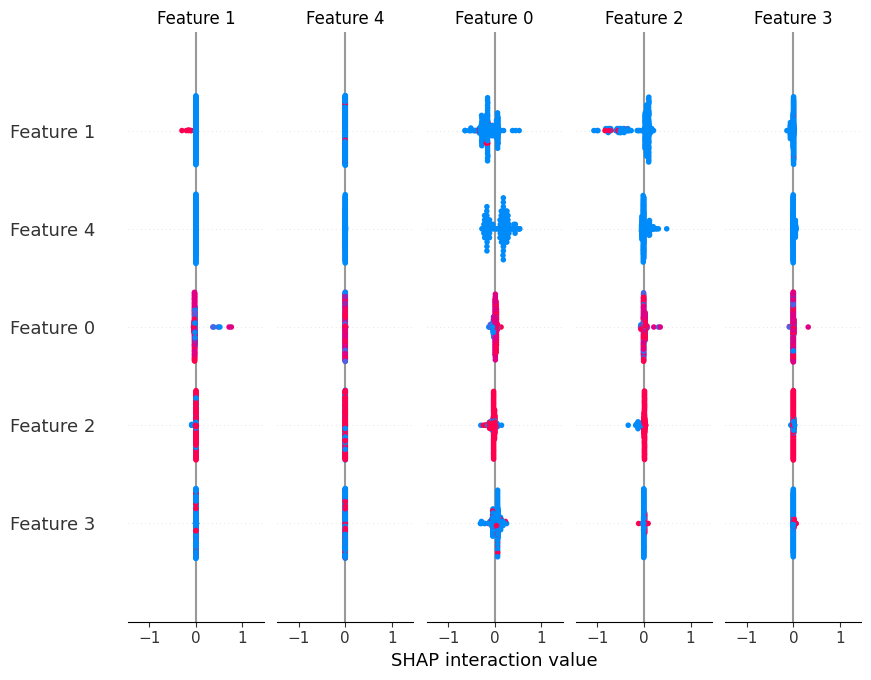

In [53]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values (use small sample to make it fast)
X_sample = X_train_smote[:200]

shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample)

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [55]:
# Save the File
import joblib

# Save Random Forest
joblib.dump(rf_random, "./models/random_forest_model.pkl")

# Save ANN
joblib.dump(ann, "./models/ann_model.pkl")

# Save XGBoost
joblib.dump(xgb_random, "./models/xgboost_model.pkl")

print("Models saved successfully!")

Models saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [56]:
# Load the File and predict unseen data.
# Load models
rf_model = joblib.load("./models/random_forest_model.pkl")
ann_model = joblib.load("./models/ann_model.pkl")
xgb_model = joblib.load("./models/xgboost_model.pkl")

# Predict on unseen test data
rf_pred = rf_model.predict(X_test)
ann_pred = ann_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Check predictions
print("RF Prediction sample:", rf_pred[:10])
print("ANN Prediction sample:", ann_pred[:10])
print("XGB Prediction sample:", xgb_pred[:10])

RF Prediction sample: [4 1 4 1 4 4 4 5 3 4]
ANN Prediction sample: [4 5 4 1 3 5 5 4 4 2]
XGB Prediction sample: [3 0 4 4 3 4 4 4 2 4]


# **Conclusion**

`In this project, a machine learning pipeline was developed to analyze customer feedback data and predict customer satisfaction levels. The dataset was first preprocessed by handling missing values, performing text preprocessing on customer remarks, encoding categorical variables, scaling numerical features, and applying dimensionality reduction where necessary.`

`The dataset was then split into training and testing sets, and class imbalance was addressed using SMOTE (Synthetic Minority Oversampling Technique) to ensure balanced model learning.`

`Three machine learning models were implemented and evaluated:`

- `Random Forest`

- `Artificial Neural Network (ANN)`

- `XGBoost`

`Among these models, XGBoost achieved the highest accuracy score (~0.455) and demonstrated better predictive performance compared to the other models. Therefore, XGBoost was selected as the final prediction model.`

`To further understand the model's decision-making process, SHAP (SHapley Additive exPlanations) was used as a model explainability tool. The SHAP analysis helped identify the most influential features contributing to customer satisfaction predictions.`

`Overall, this machine learning solution can help businesses analyze customer feedback more effectively, identify key factors affecting satisfaction, and make data-driven decisions to improve customer experience and service quality.`